In [ ]:
%load_ext autoreload
%autoreload 2


In [2]:
import sys
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")
import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path
import random

In [3]:
from analysis.utils import load_sweep_metadata, load_data, compute_success

In [4]:
# Example usage:
df_metadata = load_sweep_metadata(
    sweep_base_dirs=
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/25-12-09-cheetah-run_initial_conditions_seeds_models",
    json_file_name="episode_metadata.json")


Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/25-12-09-cheetah-run_initial_conditions_seeds_models:   0%|          | 0/30 [00:00<?, ?it/s]

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/25-12-09-cheetah-run_initial_conditions_seeds_models: 100%|██████████| 30/30 [00:00<00:00, 355.92it/s]

Found 30 configurations


In [5]:
df = load_data(df_metadata, episode_file_name="episode_data.pkl")

Found 30 configurations


100%|██████████| 30/30 [00:00<00:00, 126.58it/s]


In [7]:
df = df[df['checkpoint'] == 'ckpts/cheetah-run-3.pt']
df.shape

(10, 16)

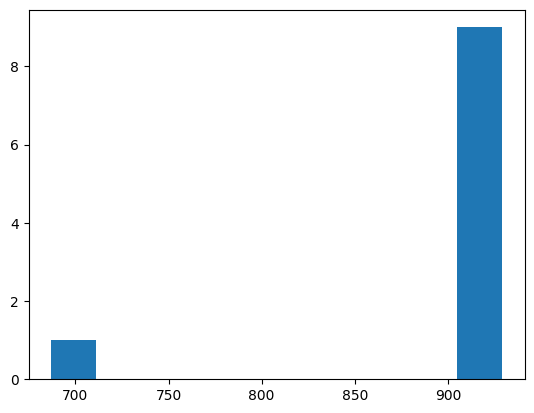

In [9]:
plt.hist(df['total_reward'])
plt.show()


In [8]:
obs = np.concatenate(df['observations'].tolist())
actions = np.concatenate(df['actions'].tolist())
z = np.concatenate(df['latent_states'].tolist())
z.shape, obs.shape, actions.shape

((5000, 512), (5000, 17), (5000, 6))

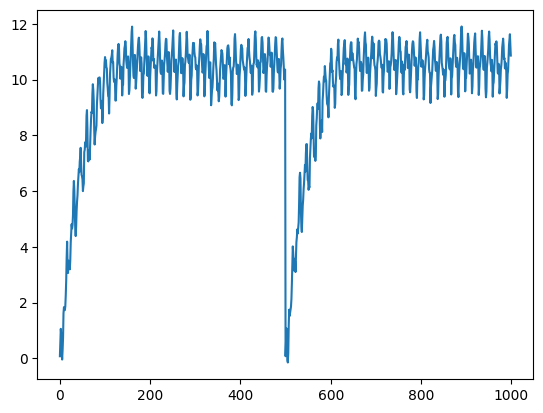

In [11]:
position = obs[:, :8]  # qpos[1:]
velocity = obs[:, 8:]  # qvel[:]  -> 9 dims
vel_torso = velocity[:, 0][:, None]
plt.plot(vel_torso[:1000])
plt.show()

In [16]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from typing import List, Dict, Any
from tqdm import tqdm


def lagged_and_delta_probes(
    Z: np.ndarray,  # (N, d) activations
    O: np.ndarray,  # (N, 5) observations
    ks: List[int] = [0, 1, 2, 3, 5, 10],
    n_shuffle: int = 5,  # shuffle baseline repeats
    random_state: int = 0,
) -> Dict[str, Dict[str, Any]]:
    """
    Runs:
      - Z_t -> x_{t+k}
      - Z_t -> Δ_k x_t
    plus baselines:
      - shuffled target
      - autocorrelation baseline

    Returns:
      results[probe_name] = {
          'r2': float,
          'shuffle_r2': float,
          'autocorr_r2': float
      }
    """
    rng = np.random.RandomState(random_state)

    assert Z.ndim == 2
    assert O.ndim == 2
    assert Z.shape[0] == O.shape[0]

    x = O[:, 0]  # cart position
    N = len(x)

    results = {}

    def fit_lr(Z_, y_, return_coef=False):
        model = LinearRegression(fit_intercept=True)
        model.fit(Z_, y_)
        y_pred = model.predict(Z_)
        if return_coef:
            return model.coef_, r2_score(y_, y_pred)
        else:
            return r2_score(y_, y_pred)

    def shuffle_baseline(Z_, y_):
        r2s = []
        for _ in range(n_shuffle):
            y_shuf = rng.permutation(y_)
            r2_score = fit_lr(Z_, y_shuf)
            r2s.append(r2_score)
        return float(np.mean(r2s)) if r2s else np.nan

    # -----------------------
    # Delta probes: Δ_k x_t
    # -----------------------
    for k in tqdm(ks, desc="Delta probes"):
        if k == 0 or k >= N:
            continue

        Zk = Z[:N - k]
        yk = x[k:] - x[:N - k]  # Δ_k

        coef_delta, r2_delta = fit_lr(Zk, yk, return_coef=True)
        shuf = shuffle_baseline(Zk, yk)

        # autocorr baseline for Δ_k
        if k + 1 < N:
            #autocorr = r2_score(x[k + 1:] - x[1:-k + 1], x[k:] - x[:-k])
            autocorr = 0.
        else:
            autocorr = np.nan

        results[f"delta_{k}"] = {
            "coef": coef_delta,
            "r2": float(r2_delta),
            "shuffle_r2": float(shuf),
            "autocorr_r2": float(autocorr),
        }

    # -----------------------
    # Lagged probes: x_{t+k}
    # -----------------------
    for k in tqdm(ks, desc="Lagged probes"):
        if k >= N:
            continue

        Zk = Z[:N - k]
        yk = x[k:]

        coef, r2 = fit_lr(Zk, yk, return_coef=True)
        shuf = shuffle_baseline(Zk, yk)

        # autocorr baseline: x_t -> x_{t+k}
        if k == 0:
            autocorr = 1.0
        else:
            autocorr = r2_score(x[k:], x[:-k])

        results[f"x_t+{k}"] = {
            "coef": coef,
            "r2": float(r2),
            "shuffle_r2": float(shuf),
            "autocorr_r2": float(autocorr),
        }

    return results


In [27]:
results = lagged_and_delta_probes(z,
                                  vel_torso,
                                  ks=[0, 5, 10, 20, 30, 40],
                                  n_shuffle=0)

for k, v in results.items():
    print(f"{k:10s} | "
          f"R²={v['r2']:+.3f} | "
          f"shuffle={v['shuffle_r2']:+.3f} | "
          f"autocorr={v['autocorr_r2']:+.3f}")


Delta probes:   0%|          | 0/6 [00:00<?, ?it/s]

Lagged probes: 100%|██████████| 6/6 [00:00<00:00, 11.16it/s]

delta_5    | R²=+0.588 | shuffle=+nan | autocorr=+0.000
delta_10   | R²=+0.479 | shuffle=+nan | autocorr=+0.000
delta_20   | R²=+0.458 | shuffle=+nan | autocorr=+0.000
delta_30   | R²=+0.410 | shuffle=+nan | autocorr=+0.000
delta_40   | R²=+0.534 | shuffle=+nan | autocorr=+0.000
x_t+0      | R²=+0.999 | shuffle=+nan | autocorr=+1.000
x_t+5      | R²=+0.869 | shuffle=+nan | autocorr=+0.683
x_t+10     | R²=+0.754 | shuffle=+nan | autocorr=+0.528
x_t+20     | R²=+0.591 | shuffle=+nan | autocorr=+0.246
x_t+30     | R²=+0.489 | shuffle=+nan | autocorr=+0.133
x_t+40     | R²=+0.437 | shuffle=+nan | autocorr=-0.210


## ADD RANDOM DIRECTIONS

In [28]:
import numpy as np

rng = np.random.default_rng(42)
n_random_directions = 3
for i in range(n_random_directions):
    random_direction = rng.standard_normal(z.shape[1])
    random_direction = random_direction / np.linalg.norm(random_direction)
    results[f"random_{i}"] = {
        "coef": random_direction,
    }

results.keys()

dict_keys(['delta_5', 'delta_10', 'delta_20', 'delta_30', 'delta_40', 'x_t+0', 'x_t+5', 'x_t+10', 'x_t+20', 'x_t+30', 'x_t+40', 'random_0', 'random_1', 'random_2'])

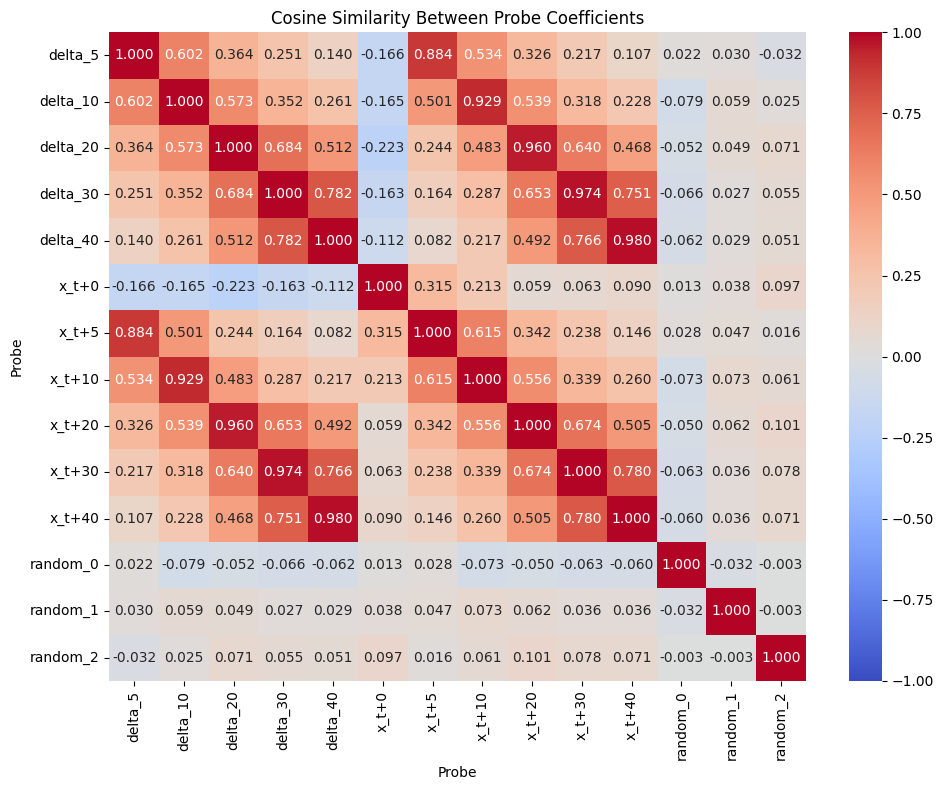

In [29]:
# Compute cosine similarity between coefficients
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Extract coefficients from results
coef_dict = {}
for k, v in results.items():
    if 'coef' in v:
        coef_dict[k] = v['coef']

# Create matrix of coefficients
keys = list(coef_dict.keys())
coef_matrix = np.array([coef_dict[k] for k in keys])

# Compute cosine similarity
similarity_matrix = cosine_similarity(coef_matrix)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix,
            annot=True,
            fmt='.3f',
            xticklabels=keys,
            yticklabels=keys,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            center=0)
plt.title('Cosine Similarity Between Probe Coefficients')
plt.xlabel('Probe')
plt.ylabel('Probe')
plt.tight_layout()
plt.show()

In [30]:
# Save coefficients to file
path_to_save_data = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/25-12-19-control-cheetah-velocity-probe'
with open(f'{path_to_save_data}/w_velocity_probes_coef.pkl', 'wb') as f:
    pickle.dump(results, f)

print("Coefficients saved to lagged_delta_coefs.pkl")

Coefficients saved to lagged_delta_coefs.pkl
